In [1]:
#Import Libraries
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve

In [2]:
#Comments in bold
bold_start = '\033[1m'
bold_end = '\033[0m'

In [3]:
# Importar Dataframes
startup_failures_df = pd.read_csv('C:/Users/ax22180/practice/startup_failures/startupfailures.csv')
finance_insurance_df = pd.read_csv('C:/Users/ax22180/practice/startup_failures/Startup Failure (Finance and Insurance).csv')
food_services_df = pd.read_csv('C:/Users/ax22180/practice/startup_failures/Startup Failure (Food and services).csv')
health_care_df = pd.read_csv('C:/Users/ax22180/practice/startup_failures/Startup Failure (Health Care).csv')
manufactures_df = pd.read_csv('C:/Users/ax22180/practice/startup_failures/Startup Failure (Manufactures).csv')
retail_df = pd.read_csv('C:/Users/ax22180/practice/startup_failures/Startup Failure (Retail Trade).csv')
information_df = pd.read_csv('C:/Users/ax22180/practice/startup_failures/Startup Failures (Information Sector).csv')

In [4]:
print(f"{bold_start}Startup Failures Dataframe:{bold_end}")
startup_failures_df.info()
#print()
print(f"{bold_start}Startup Failure (Finance and Insurance) Dataframe:{bold_end}")
finance_insurance_df.info()
print()
print(f"{bold_start}Startup Failure (Food and services) Dataframe:{bold_end}")
food_services_df.info()
print()
print(f"{bold_start}Startup Failure (Health Care) Dataframe:{bold_end}")
health_care_df.info()
print()
print(f"{bold_start}Startup Failure (Manufactures) Dataframe:{bold_end}")
manufactures_df.info()
print()
print(f"{bold_start}Startup Failure (Retail Trade) Dataframe:{bold_end}")
retail_df.info()
print()
print(f"{bold_start}Startup Failures (Information Sector) Dataframe:{bold_end}")
information_df.info()

Startup Failures Dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Name                815 non-null    object
 1   Sector              815 non-null    object
 2   Years of Operation  815 non-null    object
dtypes: object(3)
memory usage: 19.2+ KB
Startup Failure (Finance and Insurance) Dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    47 non-null     object 
 1   Sector                  47 non-null     object 
 2   Years of Operation      47 non-null     object 
 3   What They Did           47 non-null     object 
 4   How Much They Raised    47 non-null     object 
 5   Why They Failed         47 non-null     object 
 6   Take

In [5]:
# Check missing values
print(f"{bold_start}Number of missing values in Startup Failure (Finance and Insurance):{bold_end}")
print(finance_insurance_df.isna().sum())

Number of missing values in Startup Failure (Finance and Insurance):
Name                      0
Sector                    0
Years of Operation        0
What They Did             0
How Much They Raised      0
Why They Failed           0
Takeaway                  0
Giants                    0
No Budget                 0
Competition               0
Poor Market Fit           0
Acquisition Stagnation    0
Platform Dependency       0
Monetization Failure      0
Niche Limits              0
Execution Flaws           0
Trend Shifts              0
Toxicity/Trust Issues     0
Regulatory Pressure       0
Overhype                  1
dtype: int64


In [6]:
# Fill missing values with Zero in Dataframe 'Startup Failure (Finance and Insurance)'
finance_insurance_df = finance_insurance_df.fillna(0)
finance_insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    47 non-null     object 
 1   Sector                  47 non-null     object 
 2   Years of Operation      47 non-null     object 
 3   What They Did           47 non-null     object 
 4   How Much They Raised    47 non-null     object 
 5   Why They Failed         47 non-null     object 
 6   Takeaway                47 non-null     object 
 7   Giants                  47 non-null     int64  
 8   No Budget               47 non-null     int64  
 9   Competition             47 non-null     int64  
 10  Poor Market Fit         47 non-null     int64  
 11  Acquisition Stagnation  47 non-null     int64  
 12  Platform Dependency     47 non-null     int64  
 13  Monetization Failure    47 non-null     int64  
 14  Niche Limits            47 non-null     int6

In [7]:
# Concat datasets 
food_services_df = food_services_df.drop('High Operational Costs', axis=1)
df_startups_failure = pd.concat([finance_insurance_df, food_services_df, health_care_df, manufactures_df, retail_df, information_df ], axis=0)
print(df_startups_failure.sample(10))
print(f"{bold_start}The 'df_startups_failure' has the following number of rows & columns:{bold_end}")
df_startups_failure.shape

               Name                 Sector Years of Operation  \
62            Raise           Retail Trade      9 (2013-2022)   
56         Pets.com           Retail Trade      2 (1998-2000)   
80   Substack Local            Information      3 (2020-2023)   
23           Ginger            Health Care          2011-2021   
5        BeagleBone          Manufacturing          2011-2018   
18           Pawngo  Finance and Insurance          2011-2017   
118    Zendesk Chat            Information      8 (2015-2023)   
28           Gimlet            Information      7 (2014-2021)   
71           Spring           Retail Trade      6 (2013-2019)   
46      Maker Media            Information     14 (2005-2019)   

                    What They Did How Much They Raised  \
62          Gift card marketplace                 $60M   
56     Online pet supply retailer                $300M   
80       Local newsletter funding    $82.4M (Substack)   
23          Mental health support                $22

(409, 20)

In [8]:
# Rename columns
columns_df_startups_failure = df_startups_failure.columns
# Replace double spaces in column names
columns_df_startups_failure = columns_df_startups_failure.str.replace('  ', ' ')
columns_df_startups_failure_low = []

#Function to add underscore before finding an uppercase
def add_scripts(columns_df_startups_failure_low):
    result = ""
    for i, caracter in enumerate(column_name):
        if i != 0 and caracter == ' ':
            result += "_"
        else:
            result += caracter
        
    return result.lower()

# Bucle FOR to apply 'add_scripts' function for every columns_contracts member
for column_name in columns_df_startups_failure:
    columns_df_startups_failure_low.append(add_scripts(column_name))

df_startups_failure.columns = columns_df_startups_failure_low
df_startups_failure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 155
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    409 non-null    object 
 1   sector                  409 non-null    object 
 2   years_of_operation      409 non-null    object 
 3   what_they_did           409 non-null    object 
 4   how_much_they_raised    409 non-null    object 
 5   why_they_failed         409 non-null    object 
 6   takeaway                409 non-null    object 
 7   giants                  409 non-null    int64  
 8   no_budget               409 non-null    int64  
 9   competition             409 non-null    int64  
 10  poor_market_fit         409 non-null    int64  
 11  acquisition_stagnation  409 non-null    int64  
 12  platform_dependency     383 non-null    float64
 13  monetization_failure    409 non-null    int64  
 14  niche_limits            409 non-null    int64  

In [9]:
print(f"{bold_start}Missing values by column:{bold_end}")
print(df_startups_failure.isna().sum())

Missing values by column:
name                       0
sector                     0
years_of_operation         0
what_they_did              0
how_much_they_raised       0
why_they_failed            0
takeaway                   0
giants                     0
no_budget                  0
competition                0
poor_market_fit            0
acquisition_stagnation     0
platform_dependency       26
monetization_failure       0
niche_limits               0
execution_flaws            0
trend_shifts               0
toxicity/trust_issues     26
regulatory_pressure       26
overhype                  26
dtype: int64


In [10]:
# Replace 'nan' by zeros
df_startups_failure = df_startups_failure.fillna(0)
print(df_startups_failure.isna().sum())

name                      0
sector                    0
years_of_operation        0
what_they_did             0
how_much_they_raised      0
why_they_failed           0
takeaway                  0
giants                    0
no_budget                 0
competition               0
poor_market_fit           0
acquisition_stagnation    0
platform_dependency       0
monetization_failure      0
niche_limits              0
execution_flaws           0
trend_shifts              0
toxicity/trust_issues     0
regulatory_pressure       0
overhype                  0
dtype: int64


In [11]:
# Modify data type 
df_startups_failure['platform_dependency'] = df_startups_failure['platform_dependency'].astype('int64')
df_startups_failure['toxicity/trust_issues'] = df_startups_failure['toxicity/trust_issues'].astype('int64')
df_startups_failure['regulatory_pressure'] = df_startups_failure['regulatory_pressure'].astype('int64')
df_startups_failure['overhype'] = df_startups_failure['overhype'].astype('int64')
df_startups_failure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 155
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   name                    409 non-null    object
 1   sector                  409 non-null    object
 2   years_of_operation      409 non-null    object
 3   what_they_did           409 non-null    object
 4   how_much_they_raised    409 non-null    object
 5   why_they_failed         409 non-null    object
 6   takeaway                409 non-null    object
 7   giants                  409 non-null    int64 
 8   no_budget               409 non-null    int64 
 9   competition             409 non-null    int64 
 10  poor_market_fit         409 non-null    int64 
 11  acquisition_stagnation  409 non-null    int64 
 12  platform_dependency     409 non-null    int64 
 13  monetization_failure    409 non-null    int64 
 14  niche_limits            409 non-null    int64 
 15  execution_f

In [12]:
print(f"{bold_start}Sector unique names:{bold_end}",df_startups_failure['sector'].unique())
print(f"{bold_start}'Giants' variable unique data:{bold_end}",df_startups_failure['giants'].unique())
print(f"{bold_start}'No budget' variable unique data:{bold_end}",df_startups_failure['no_budget'].unique())
print(f"{bold_start}'Competition' variable unique data:{bold_end}",df_startups_failure['competition'].unique())
print(f"{bold_start}'poor_market_fit' variable unique data:{bold_end}",df_startups_failure['poor_market_fit'].unique())
print(f"{bold_start}'acquisition_stagnation' variable unique data:{bold_end}",df_startups_failure['acquisition_stagnation'].unique())
print(f"{bold_start}'platform_dependency' variable unique data:{bold_end}",df_startups_failure['platform_dependency'].unique())
print(f"{bold_start}monetization_failure' variable unique data:{bold_end}",df_startups_failure['monetization_failure'].unique())
print(f"{bold_start}'niche_limits' variable unique data:{bold_end}",df_startups_failure['niche_limits'].unique())
print(f"{bold_start}'execution_flaws' variable unique data:{bold_end}",df_startups_failure['execution_flaws'].unique())
print(f"{bold_start}'trend_shifts' variable unique data:{bold_end}",df_startups_failure['trend_shifts'].unique())
print(f"{bold_start}'toxicity/trust_issues' variable unique data:{bold_end}",df_startups_failure['toxicity/trust_issues'].unique())
print(f"{bold_start}'regulatory_pressure' variable unique data:{bold_end}",df_startups_failure['regulatory_pressure'].unique())

Sector unique names: ['Finance and Insurance' 'Accommodation and Food Services' 'Health Care'
 'Manufacturing' 'Retail Trade' 'Information']
'Giants' variable unique data: [1 0]
'No budget' variable unique data: [1 0]
'Competition' variable unique data: [1 0]
'poor_market_fit' variable unique data: [0 1]
'acquisition_stagnation' variable unique data: [0 1]
'platform_dependency' variable unique data: [0 1]
monetization_failure' variable unique data: [0 1]
'niche_limits' variable unique data: [0 1]
'execution_flaws' variable unique data: [0 1]
'trend_shifts' variable unique data: [0 1]
'toxicity/trust_issues' variable unique data: [0 1]
'regulatory_pressure' variable unique data: [0 1]


In [13]:
# Data transformation
df_startups_failure[['start_year', 'end_year']] = df_startups_failure['years_of_operation'].str.split('-', expand=True)

# Delete parentesis from 'star year' & 'end year' columns
df_startups_failure['start_year'] = df_startups_failure['start_year'].str.replace(r'^[^(]*\(', '', regex=True)
df_startups_failure['end_year'] = df_startups_failure['end_year'].str.rstrip(')')
#print(df_startups_failure.sample(5))
print(f"{bold_start}Número de customer_id únicos:{bold_end}",df_startups_failure['start_year'].unique())
print(f"{bold_start}Número de customer_id únicos:{bold_end}",df_startups_failure['end_year'].unique())

# Modify data type of 'star year' & 'end year' columns
df_startups_failure['start_year'] = df_startups_failure['start_year'].astype('int64')
df_startups_failure['end_year'] = df_startups_failure['end_year'].astype('int64')
df_startups_failure.info()
# Calculate the 'years_of_operation' columns
df_startups_failure['year_of_operation']= df_startups_failure['end_year'] - df_startups_failure['start_year']
#print(df_startups_failure.sample(5))



Número de customer_id únicos: ['2012' '2002' '2006' '2013' '2016' '2011' '2021' '2010' '2014' '2008'
 '2005' '2015' '2009' '2003' '2007' '2018' '2017' '2019' '2004' '1998'
 '1996' '1994' '1999' '2020' '1979' '2000']
Número de customer_id únicos: ['2023' '2008' '2011' '2022' '2016' '2019' '2020' '2021' '2017' '2018'
 '2007' '2013' '2015' '2014' '2024' '2002' '2000' '1999' '2012' '2005'
 '2003' '1984' '2010']
<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 155
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   name                    409 non-null    object
 1   sector                  409 non-null    object
 2   years_of_operation      409 non-null    object
 3   what_they_did           409 non-null    object
 4   how_much_they_raised    409 non-null    object
 5   why_they_failed         409 non-null    object
 6   takeaway                409 non-null    object
 7   giants          

In [14]:
# Clean 'how_much_they_raised_clean' column
df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised'].str.replace('$', ' ')
df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised_clean'].str.replace('+', ' ')
df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised_clean'].str.replace('acquisition', ' ')
df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised_clean'].str.replace('pre-orders', ' ')
df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised_clean'].str.replace(' lowM', '0')
df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised_clean'].str.replace(r'\([^)]*\)', '', regex=True)
df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised_clean'].str.replace('$lowM', '0')

# Function to convert all values to the same units, millions of dollars. 
def convert_to_millons(value):
    # step 1: clean spaces
    clean_value = value.strip()
    
    # step 2: special cases
    if clean_value == '0':
        return 0
    
    # step 3: verify if there are multiple values
    if '  ' in clean_value:  # two spaces 
        # split & sum values
        parts = clean_value.split()
        total = 0
        for parts in parts:
            if parts:  # if it is not empty 
                total += convert_value_individual(parts)
        return total
    
    # Paso 4: Convertir valor individual
    return convert_value_individual(clean_value)

def convert_value_individual(value):
    if 'B' in value:
        # remove "B" & convert to float, then multiply by 1000
        number = float(value.replace('B', ''))
        return number * 1000
    elif 'M' in value:
        # remove 'M' & convert too float
        number = float(value.replace('M', ''))
        return number
    else:
        return float(value)

df_startups_failure['how_much_they_raised_clean'] = df_startups_failure['how_much_they_raised_clean'].apply(convert_to_millons)

df_startups_failure.info()


<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 155
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        409 non-null    object 
 1   sector                      409 non-null    object 
 2   years_of_operation          409 non-null    object 
 3   what_they_did               409 non-null    object 
 4   how_much_they_raised        409 non-null    object 
 5   why_they_failed             409 non-null    object 
 6   takeaway                    409 non-null    object 
 7   giants                      409 non-null    int64  
 8   no_budget                   409 non-null    int64  
 9   competition                 409 non-null    int64  
 10  poor_market_fit             409 non-null    int64  
 11  acquisition_stagnation      409 non-null    int64  
 12  platform_dependency         409 non-null    int64  
 13  monetization_failure        409 non-null

<div class="alert alert-block alert-info">

<b>Columns explanation</b>  <a class="tocSkip"></a>

<b>Name</b>: The startup’s name.

<b>Sector</b>: Industry classification (all "Information" here, NAICS 51).

<b>Years of Operation</b>: Lifespan in years, with founding and shutdown years (e.g., "3 (2010-2013)").

<b>What They Did</b>: Brief overview of the startup’s product or service.

<b>How Much They Raised</b>: Funding amount in millions ($M) or tied to parent totals (e.g., "$1.7B (Dropbox)").

<b>Why They Failed</b>: Reason the startup ceased or faded as a standalone entity.

<b>Takeaway</b>: Key lesson derived from the failure.

<b>Giants</b>: 1 if lost to tech giants (e.g., Google, Amazon), 0 if not.

<b>No Budget</b>: 1 if ran out of cash or was underfunded, 0 if not.

<b>Competition</b>: 1 if outpaced by direct rivals (not just giants), 0 if not.

<b>Poor Market Fit</b>: 1 if product lacked demand or user interest, 0 if not.

<b>Acquisition Stagnation</b>: 1 if stagnated or faded after acquisition, 0 if not.

<b>Platform Dependency</b>: 1 if overly reliant on another platform (e.g., Twitter), 0 if not.

<b>Monetization Failure</b>: 1 if couldn’t turn users into revenue, 0 if not.

<b>Niche Limits</b>: 1 if too niche to scale broadly, 0 if not.

<b>Execution Flaws</b>: 1 if mismanagement or tech failures contributed, 0 if not.

<b>Trend Shifts</b>: 1 if market or user trends shifted away, 0 if not.

<b>Toxicity/Trust Issues</b>: 1 if user toxicity or trust breaches hurt, 0 if not.

<b>Regulatory Pressure</b>: 1 if legal or regulatory issues forced closure, 0 if not.

<b>Overhype</b>: 1 if hype exceeded deliverable results, 0 if not.

</div>

C:\Users\ax22180\AppData\Local\Temp\ipykernel_24740\1274074453.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


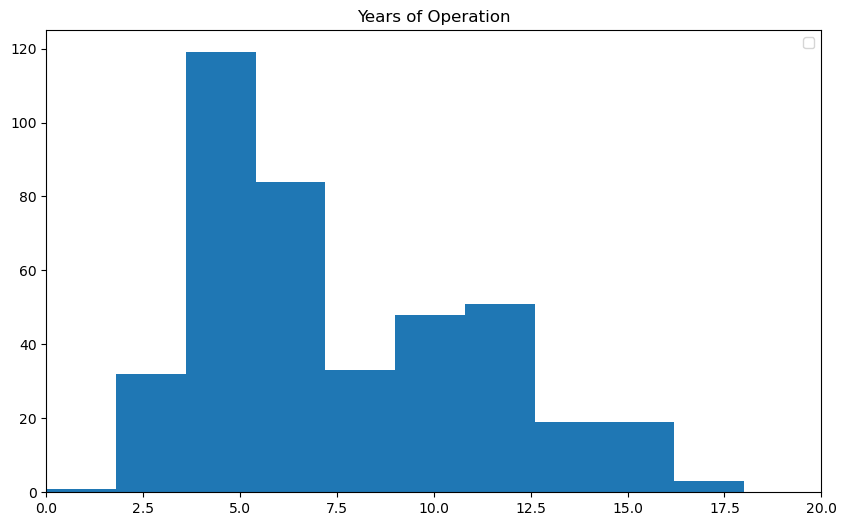

In [15]:
# Exploratory Data Analysis by Sector
# Failure profile

plt.figure(figsize=(10, 6))

duration =  df_startups_failure['year_of_operation']

plt.hist(duration)

plt.title('Years of Operation')
plt.legend()
plt.xlim(0, 20)

plt.show()


In [16]:
skewness = df_startups_failure['year_of_operation'].skew()
print(f"{bold_start}Year of operation Skewness:{bold_end} {skewness:.3f}")

if abs(skewness) < 0.5:
    print("Approximately symmetrical distribution")
elif 0.5 <= abs(skewness) < 1:
    print("Moderately skewed distribution")
else:
    print(f"Highly skewed distribution (|skew| = {abs(skewness):.2f})")

skewness = df_startups_failure['how_much_they_raised_clean'].skew()
print(f"{bold_start}Fundraising Raised Skewness:{bold_end} {skewness:.3f}")

if abs(skewness) < 0.5:
    print("Approximately symmetrical distribution")
elif 0.5 <= abs(skewness) < 1:
    print("Moderately skewed distribution")
else:
    print(f"Highly skewed distribution (|skew| = {abs(skewness):.2f})")

Year of operation Skewness: 0.671
Moderately skewed distribution
Fundraising Raised Skewness: 4.946
Highly skewed distribution (|skew| = 4.95)


In [17]:
print(f"{bold_start}Years of operation statistics:{bold_end}")
df_startups_failure['year_of_operation'].describe()

Years of operation statistics:


count    409.000000
mean       7.515892
std        3.525866
min        0.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       18.000000
Name: year_of_operation, dtype: float64

In [18]:
print(f"{bold_start}Funding statistics:{bold_end}")
df_startups_failure['how_much_they_raised_clean'].describe()

Funding statistics:


count     409.000000
mean      147.253729
std       343.157636
min         0.000000
25%         5.000000
50%        28.500000
75%       120.000000
max      3500.000000
Name: how_much_they_raised_clean, dtype: float64

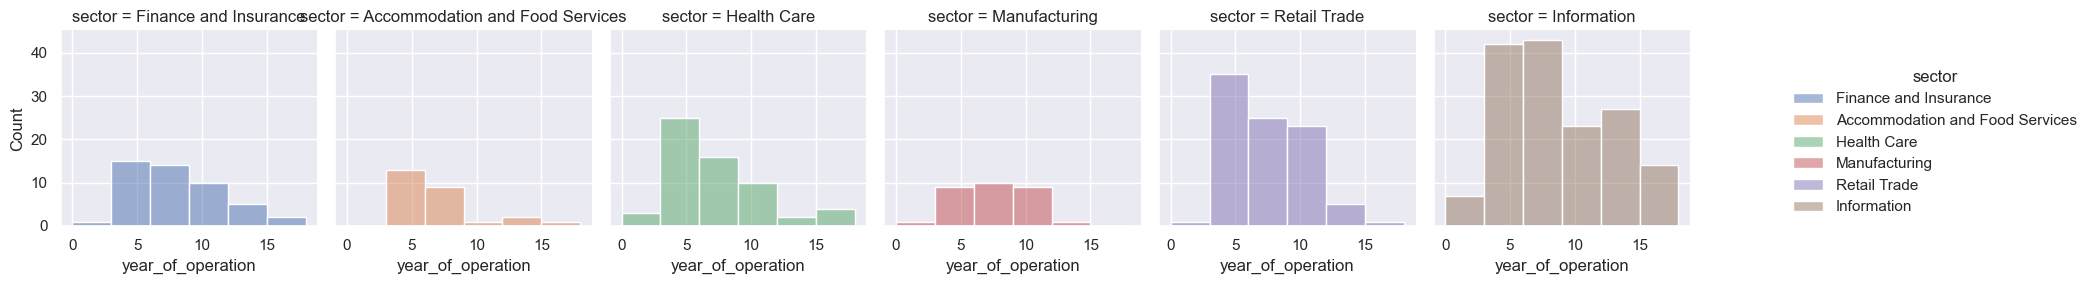

In [19]:
# Year of operation by sector
sns.set_theme(style="darkgrid")
df = df_startups_failure

sns.displot(
    df, x="year_of_operation", col="sector", hue="sector",
    binwidth=3, height=3, facet_kws=dict(margin_titles=True),
)

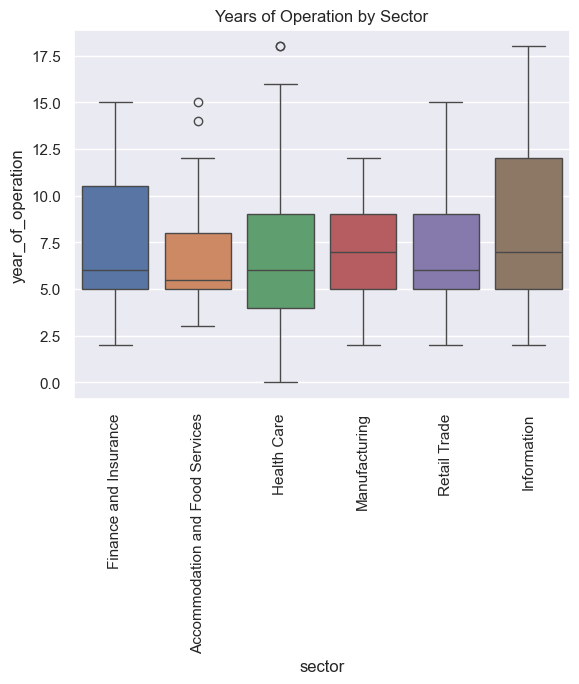

Years of operation by sector statistics:
sector    Accommodation and Food Services  Finance and Insurance  Health Care  \
count                           26.000000              47.000000    60.000000   
mean                             6.692308               7.595745     6.850000   
var                              9.261538              10.637373    13.994068   
std                              3.043278               3.261499     3.740865   
median                           5.500000               6.000000     6.000000   
min                              3.000000               2.000000     0.000000   
Q1 (25%)                         5.000000               5.000000     4.000000   
Q3 (75%)                         8.000000              10.500000     9.000000   
max                             15.000000              15.000000    18.000000   

sector    Information  Manufacturing  Retail Trade  
count      156.000000      30.000000     90.000000  
mean         8.282051       6.966667      

In [20]:
# Boxplot & satistics by sector
sns.boxplot(data=df_startups_failure, x='sector', y='year_of_operation', hue="sector")
plt.title('Years of Operation by Sector')
plt.xticks(rotation=90)  # Rotar etiquetas si son largas
plt.show()

def custom_describe(series):
    stats = series.agg([
        'count',
        'mean',
        'var',       
        'std',       
        'median',    
        'min',
        lambda x: x.quantile(0.25),  
        lambda x: x.quantile(0.75),  
        'max'
    ])
    stats.index = [
        'count',
        'mean',
        'var',       
        'std',       
        'median',    
        'min',
        'Q1 (25%)', 
        'Q3 (75%)', 
        'max'
    ]
    return stats

stats_by_sector = df_startups_failure.groupby('sector')['year_of_operation'].apply(custom_describe)

stats_table = stats_by_sector.unstack().T 
print("Years of operation by sector statistics:")
print(stats_table)


<div class="alert alert-block alert-info">

<b>Columns explanation</b>  <a class="tocSkip"></a>

When comparing the statistics of the six sectors, we can see the following:
- All sectors have a similar median between 5,5 and 7 years of average years of operation. Being the Accomodation and Food Services the sector with the lowest median, meaning the lowest years of operation. On the other hand, Information & Manufacturing have the highets average years of operation. 
- All sector has an approximately standard deviation around 3 years. Manufacturing has the lowest standard deviation (2,78 years) meanning that it will be the easier to make predictions. On the other hand, Information has the highest std. deviation.  

</div>

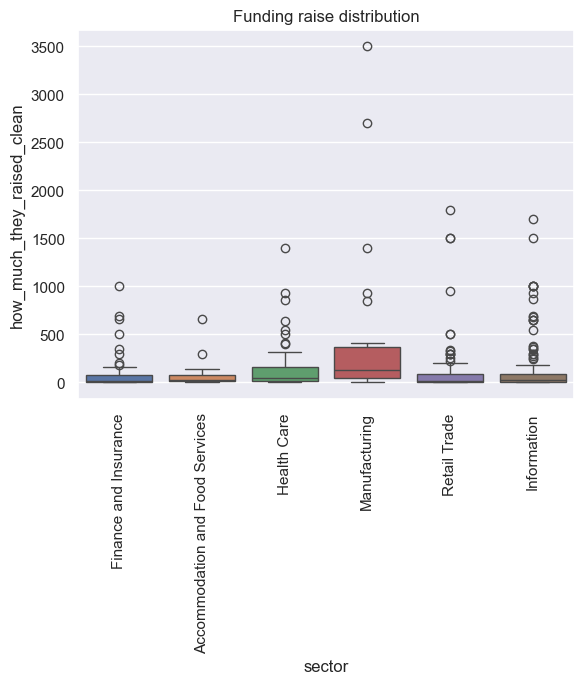

Funding raise statistics by sector:
sector    Accommodation and Food Services  Finance and Insurance  \
count                           26.000000              47.000000   
mean                            72.269231             101.614894   
var                          18650.204615           44221.757382   
std                            136.565752             210.289699   
median                          20.000000              11.000000   
min                              1.000000               0.000000   
Q1 (25%)                        10.000000               2.500000   
Q3 (75%)                        76.000000              72.500000   
max                            660.000000            1000.000000   

sector     Health Care   Information  Manufacturing  Retail Trade  
count        60.000000    156.000000      30.000000     90.000000  
mean        154.358333    129.689583     419.900000    127.575556  
var       66581.966879  76924.056782  641598.231034  95802.046362  
std        

In [21]:
# Funding raise distribution analysis 
# Boxplot & satistics by sector
sns.boxplot(data=df_startups_failure, x='sector', y='how_much_they_raised_clean', hue="sector")
plt.title('Funding raise distribution')
plt.xticks(rotation=90)  # Rotar etiquetas si son largas
plt.show()

def custom_describe(series):
    stats = series.agg([
        'count',
        'mean',
        'var',       
        'std',       
        'median',    
        'min',
        lambda x: x.quantile(0.25),  
        lambda x: x.quantile(0.75),  
        'max'
    ])
    stats.index = [
        'count',
        'mean',
        'var',       
        'std',       
        'median',    
        'min',
        'Q1 (25%)', 
        'Q3 (75%)', 
        'max'
    ]
    return stats

stats_by_sector = df_startups_failure.groupby('sector')['how_much_they_raised_clean'].apply(custom_describe)

stats_table = stats_by_sector.unstack().T 
print("Funding raise statistics by sector:")
print(stats_table)

Correlation years of operation / funding raise: 0.1292


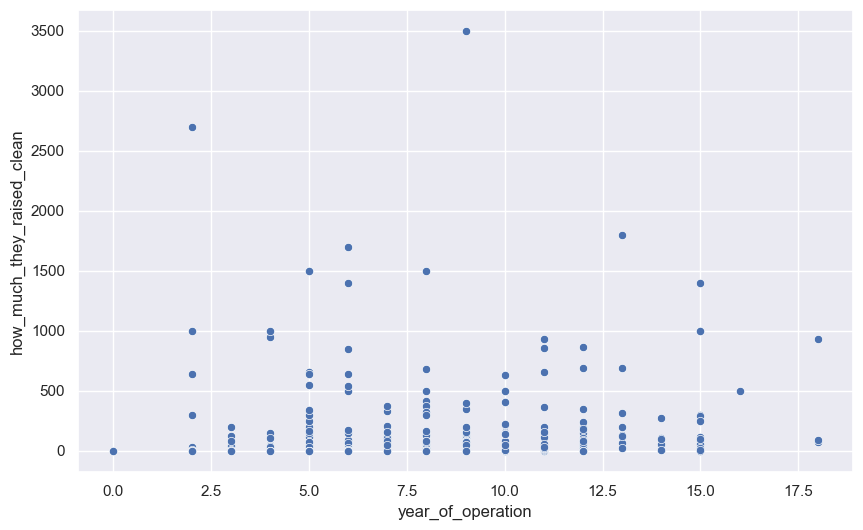

In [22]:
# Scatter plot Years of Operation versus Funding raise
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="year_of_operation", y="how_much_they_raised_clean")

# Correlation years of operation / funding raise
operation_funding_corr = df_startups_failure['how_much_they_raised_clean'].corr(df_startups_failure['year_of_operation']).round(4)
print(f"{bold_start}Correlation years of operation / funding raise:{bold_end}",operation_funding_corr)

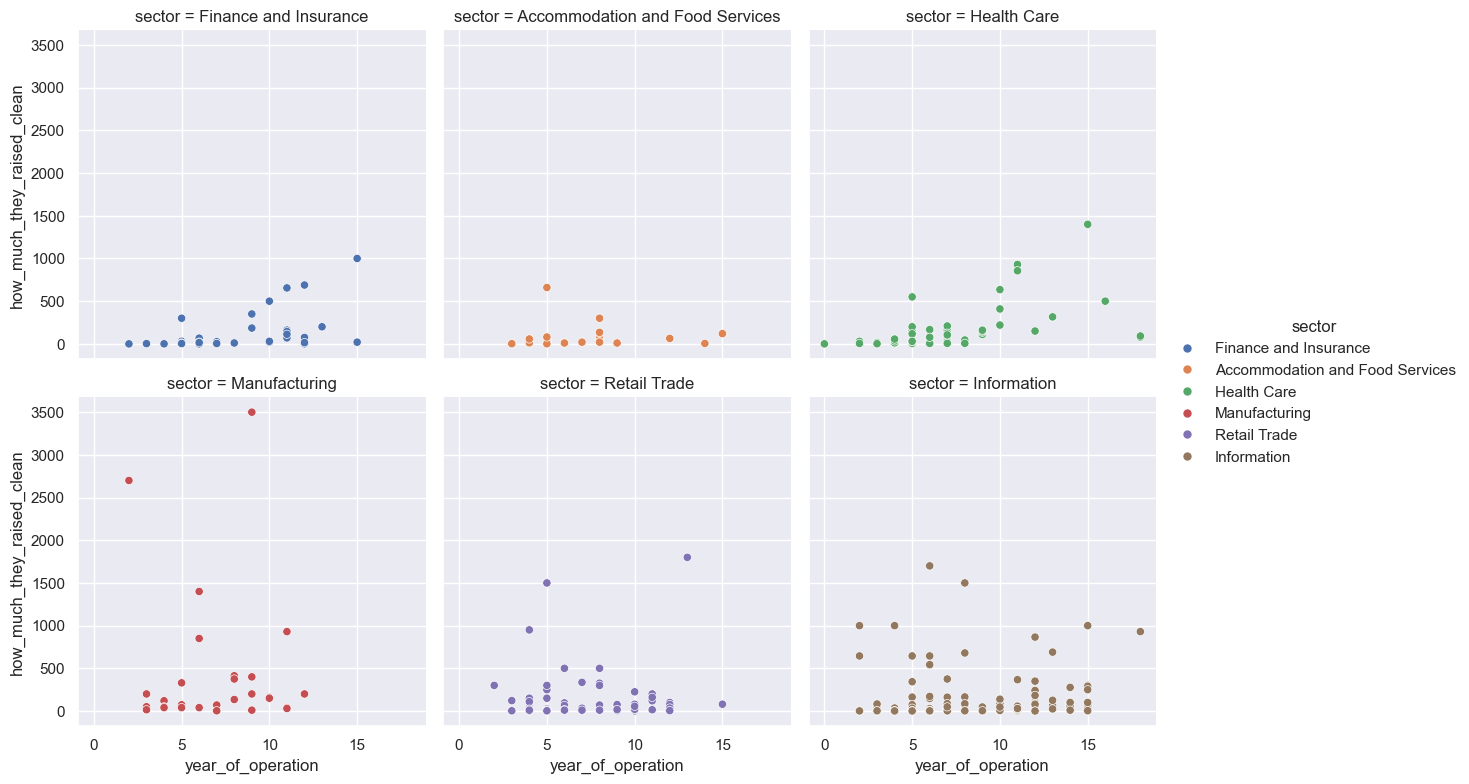

Correlation for Finance and Insurance: 0.5345
Correlation for Accommodation and Food Services: 0.0529
Correlation for Health Care: 0.543
Correlation for Manufacturing: -0.0444
Correlation for Retail Trade: 0.0479
Correlation for Information: 0.1128


In [23]:
# # Scatter plot Years of Operation versus Funding raise by sector
sns.relplot(
    data=df_startups_failure, 
    x="year_of_operation", 
    y="how_much_they_raised_clean",
    col="sector",
    kind="scatter",
    col_wrap=3, 
    height=4,
    hue='sector'
)
plt.show()

for sector in df_startups_failure['sector'].unique():
    df_sector = df_startups_failure[df_startups_failure['sector'] == sector]
    corr = df_sector['how_much_they_raised_clean'].corr(df_sector['year_of_operation']).round(4)
    print(f"{bold_start}Correlation for {sector}:{bold_end}", corr)


<div class="alert alert-block alert-info">

<b>Columns explanation</b>  <a class="tocSkip"></a>

Correlation conclusions between Years of Operation & Funding raise:
- The total correlation of the whole dataset is 0.1292, it means there is a weak correlation between the two variables. It means that the funding raise does not have an influence over years of operation.
- When correlation is calculated by sectors, the results change considerably:
  
  For Finance & Insurance and Health Care, the correlation is 0.5, meaning that funding has a positive correlation with years of operation.
  
  For the other sectors, it is closed to 0 and for Manufacturing is 0 negative.
- It could lead to the conclusion that for specific sectors the funding raise could be more important than other ones. For example, Health Care should have higher funding than other sectors due to the equipment and profesionals (physicians, especialist, etc) that it requieres. 

</div>

In [24]:
# Outliers analysis high funding & low years of operation 
Q3 = df_startups_failure['how_much_they_raised_clean'].quantile(0.75)
df_startups_failure_outliers = df_startups_failure.query("how_much_they_raised_clean > @Q3 & year_of_operation < 7") 

print(df_startups_failure_outliers)

                      name                           sector  \
19            Pay By Touch            Finance and Insurance   
21             Zomato Base  Accommodation and Food Services   
35                  Kyruus                      Health Care   
43           Modern Health                      Health Care   
46            Omada Health                      Health Care   
47          Outset Medical                      Health Care   
6             Better Place                    Manufacturing   
9       Dyson's EV Project                    Manufacturing   
11      Essential Products                    Manufacturing   
13       Fisker Automotive                    Manufacturing   
14             GoPro Karma                    Manufacturing   
5                    Beepi                     Retail Trade   
25              Gilt Taste                     Retail Trade   
29             Groupon Now                     Retail Trade   
56                Pets.com                     Retail T

In [25]:
#Main Outliers' failure causes 
causes_columns = ['giants', 'no_budget', 'competition','poor_market_fit','acquisition_stagnation','platform_dependency','monetization_failure',
                  'niche_limits', 'execution_flaws', 'trend_shifts', 'toxicity/trust_issues', 'regulatory_pressure', 'overhype']

groupby_data = df_startups_failure_outliers.groupby(['sector'])[causes_columns].sum()
groupby_data = groupby_data.loc[groupby_data.sum(axis=1).sort_values(ascending=False).index]


styled_table = groupby_data.style.background_gradient(cmap='YlOrRd')
styled_table

,giants,no_budget,competition,poor_market_fit,acquisition_stagnation,platform_dependency,monetization_failure,niche_limits,execution_flaws,trend_shifts,toxicity/trust_issues,regulatory_pressure,overhype
sector,,,,,,,,,,,,,
Retail Trade,7,3,4,3,1,0,4,1,3,3,0,0,2
Information,7,0,10,1,2,0,3,0,0,1,0,0,0
Manufacturing,5,4,5,0,0,1,0,0,2,0,0,0,2
Health Care,2,1,2,2,0,0,1,0,2,0,0,0,0
Finance and Insurance,1,0,1,0,0,0,0,0,1,0,0,0,0
Accommodation and Food Services,0,0,1,0,0,0,0,0,0,0,0,0,0


In [26]:
# #Main failure causes without Outliers

df_without_outliers = df_startups_failure.query("how_much_they_raised_clean <= @Q3 | year_of_operation >= 7")
groupby_data = df_without_outliers.groupby(['sector'])[causes_columns].sum()
groupby_data = groupby_data.loc[groupby_data.sum(axis=1).sort_values(ascending=False).index]

styled_table = groupby_data.style.background_gradient(cmap='YlOrRd')
styled_table

,giants,no_budget,competition,poor_market_fit,acquisition_stagnation,platform_dependency,monetization_failure,niche_limits,execution_flaws,trend_shifts,toxicity/trust_issues,regulatory_pressure,overhype
sector,,,,,,,,,,,,,
Information,108,12,105,8,52,5,16,16,11,18,9,3,4
Retail Trade,57,14,40,17,6,1,13,29,17,8,6,3,3
Health Care,32,22,33,26,10,0,17,7,14,5,5,5,5
Finance and Insurance,44,3,46,11,12,0,1,9,2,2,3,3,1
Manufacturing,25,12,25,7,4,0,0,4,6,5,0,0,3
Accommodation and Food Services,20,6,19,6,4,0,2,3,2,2,0,0,0


<div class="alert alert-block alert-info">

<b>Failure causes conclusions:</b>  <a class="tocSkip"></a>

1. For ouliers and the non-outliers in all sectors the two main failure causes are giants & competition with companies like Tesla, Apple, Samsumg, 
WallMart, Amazon, Notion, Spotify and Google. 
2. Other important failure causes are:
- Health: No_Budget
- Retail: niche_limits & execution_flaws
- Information: trend_shifts & toxicity/trust_issues
  
</div>

In [27]:
# Feature Engineering
# The process of transforming data into models language (avoiding garbabe in, garbage out). 
# Benefits: Improve accuracy, Reduce overfitting, Boost interpretability, Enhance efficiency.

# Year of operation stats
stats = {
    'mean': df_startups_failure['year_of_operation'].mean(),
    'median': df_startups_failure['year_of_operation'].median(),
    'mode': df_startups_failure['year_of_operation'].mode()[0],
    'Q1': df_startups_failure['year_of_operation'].quantile(0.25),
    'Q3': df_startups_failure['year_of_operation'].quantile(0.75),
    'skewness': df_startups_failure['year_of_operation'].skew(),
    'kurtosis': df_startups_failure['year_of_operation'].kurtosis()
}

print("Original Distribution:")
for key, value in stats.items():
    print(f"{key}: {value:.2f}")

Original Distribution:
mean: 7.52
median: 7.00
mode: 5.00
Q1: 5.00
Q3: 10.00
skewness: 0.67
kurtosis: -0.27


In [28]:
# Feature engineering for 'year_of_operation' variable

# 1. Keep original transformed
df_startups_failure['years_log']= np.log1p(df_startups_failure['year_of_operation'])
    
# 2. Strategic binary variables
df_startups_failure['over_3_years']= (df_startups_failure['year_of_operation'] >= 3).astype(int)
df_startups_failure['over_5_years']= (df_startups_failure['year_of_operation'] >= 5).astype(int)
df_startups_failure['over_7_years']= (df_startups_failure['year_of_operation'] >= 7).astype(int)
df_startups_failure['over_10_years']= (df_startups_failure['year_of_operation'] >= 10).astype(int)
    
    # 3. Stage category
df_startups_failure['stage']= pd.qcut(df_startups_failure['year_of_operation'], q=4, labels=['stage1', 'stage2', 'stage3', 'stage4'])
    
    # 4. No lineal Feature
df_startups_failure['risk_decay']= np.exp(-0.3 * df_startups_failure['year_of_operation'])  # Exponential decline in risk

#print(df_startups_failure)

In [29]:
# Fundraising stats
stats = {
    'mean': df_startups_failure['how_much_they_raised_clean'].mean(),
    'median': df_startups_failure['how_much_they_raised_clean'].median(),
    'mode': df_startups_failure['how_much_they_raised_clean'].mode()[0],
    'Q1': df_startups_failure['how_much_they_raised_clean'].quantile(0.25),
    'Q3': df_startups_failure['how_much_they_raised_clean'].quantile(0.75),
    'skewness': df_startups_failure['how_much_they_raised_clean'].skew(),
    'kurtosis': df_startups_failure['how_much_they_raised_clean'].kurtosis()
}

print("Original Distribution:")
for key, value in stats.items():
    print(f"{key}: {value:.2f}")

Original Distribution:
mean: 147.25
median: 28.50
mode: 10.00
Q1: 5.00
Q3: 120.00
skewness: 4.95
kurtosis: 33.37


In [30]:
# Feature engineering for 'year_of_operation' variable
# 1. Keep original transformed
df_startups_failure['fundraising_log']= np.log1p(df_startups_failure['how_much_they_raised_clean'])

# 2. Burn rate estimated
df_startups_failure['fundraising_burn_rate']= df_startups_failure['how_much_they_raised_clean'] / df_startups_failure['year_of_operation']
# Replace infinite (if year_of_operation is 0) by NaN
df_startups_failure['fundraising_burn_rate'] = df_startups_failure['fundraising_burn_rate'].replace([np.inf, -np.inf], np.nan)
# Fill NaN by Zero
df_startups_failure['fundraising_burn_rate'] = df_startups_failure['fundraising_burn_rate'].fillna(0)
#print(df_startups_failure)

In [31]:
# One-hot-encoding for sectors
df_startups_failure = pd.get_dummies(df_startups_failure, columns=['sector'], prefix='sector', drop_first=True)
print(df_startups_failure.head())

             name years_of_operation                   what_they_did  \
0           Avant          2012-2023           Online personal loans   
1         Bitpass          2002-2008          Micropayments platform   
2  Cake Financial          2006-2011         Portfolio tracking tool   
3          Circle          2013-2023  Crypto payments and stablecoin   
4   Clarity Money          2016-2022            Personal finance app   

  how_much_they_raised                          why_they_failed  \
0                $655M    Lost to LendingClub and high defaults   
1                  $2M          Lost to PayPal and low adoption   
2                  $3M       Lost to Mint and sold to TradeKing   
3                $500M       Lost to Coinbase and market shifts   
4                 $11M  Lost to Mint/Acorns and sold to Goldman   

                      takeaway  giants  no_budget  competition  \
0   Lending needs risk balance       1          1            1   
1  Micropayments need mass use  

In [32]:
# Chi-square test of independence
# To determine if there is a significant relationship between two categorical variables, as sector & failure variable. 
# Null Hypothesis (Ho): A startup's industry has no bearing on whether it runs out of budget.
# Alternative Hypothesis (H1): Certain industries (such as healthcare or manufacturing) are inherently more prone to running out of budget 
# due to their high operating costs.

sectors = ['sector_Finance and Insurance', 'sector_Health Care', 
           'sector_Information', 'sector_Manufacturing', 'sector_Retail Trade']

results = []
for sector in sectors:
    for causes in causes_columns:
        contingency_table = pd.crosstab(df_startups_failure[sector], df_startups_failure[causes])

        chi2, p, dof, expected = chi2_contingency(contingency_table)
        results.append({
            'sector': sector,
            'failure_causes': causes,
            'p-value': round(p, 4),
            'meaningful': 'Yes' if p < 0.05 else 'No'
        })

df_chi = pd.DataFrame(results)
print(df_chi[df_chi['meaningful'] == 'Yes'])
    

                          sector          failure_causes  p-value meaningful
0   sector_Finance and Insurance                  giants   0.0011        Yes
1   sector_Finance and Insurance               no_budget   0.0339        Yes
2   sector_Finance and Insurance             competition   0.0000        Yes
6   sector_Finance and Insurance    monetization_failure   0.0238        Yes
13            sector_Health Care                  giants   0.0005        Yes
14            sector_Health Care               no_budget   0.0001        Yes
15            sector_Health Care             competition   0.0266        Yes
16            sector_Health Care         poor_market_fit   0.0000        Yes
19            sector_Health Care    monetization_failure   0.0002        Yes
21            sector_Health Care         execution_flaws   0.0081        Yes
27            sector_Information               no_budget   0.0000        Yes
29            sector_Information         poor_market_fit   0.0000        Yes

<Axes: xlabel='failure_causes', ylabel='sector'>

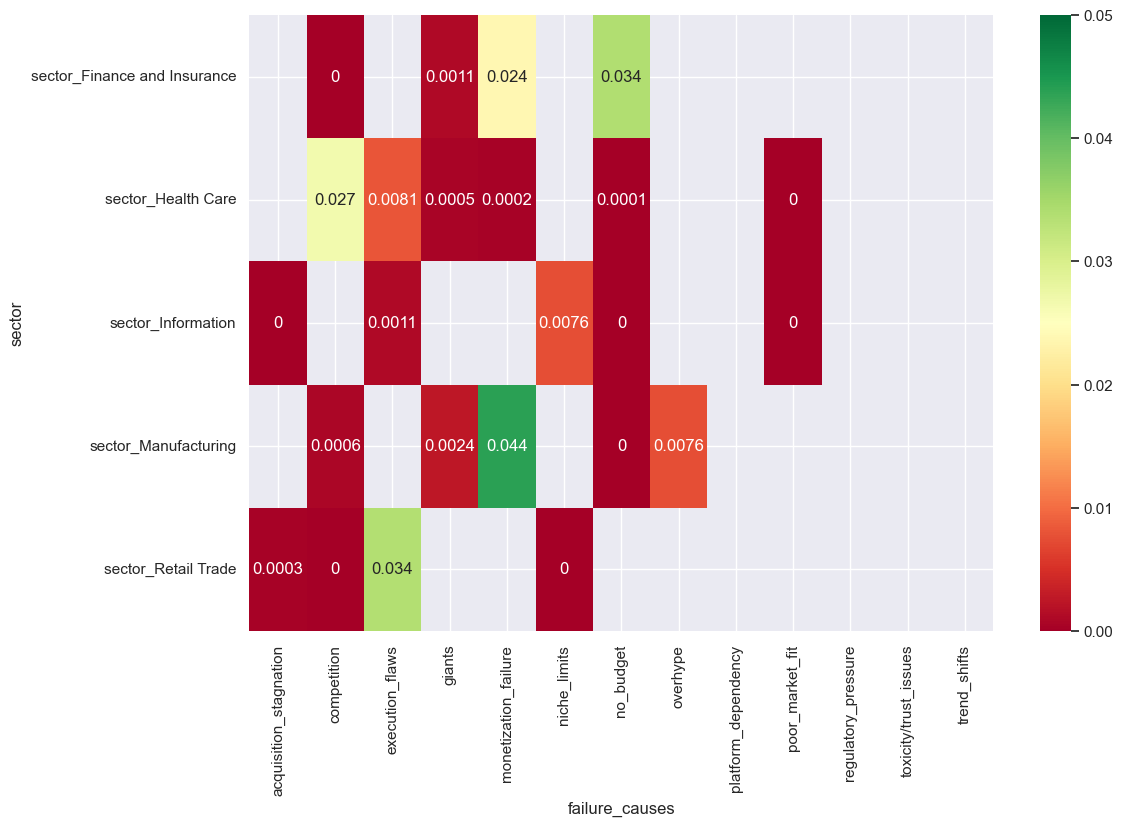

In [33]:
# Heatmap to show the Chi-square test result
df_pivot = df_chi.pivot_table(index='sector', columns = 'failure_causes', values = 'p-value')
#print(df_pivot)

# Create a mask to show only the meaningful data, it means P-value < 0.05.
matriz_p = df_chi.pivot_table(index='sector', columns = 'failure_causes', values = 'p-value')
meaningful_mask = matriz_p >= 0.05

plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot, mask = meaningful_mask, cmap = 'RdYlGn', annot= True, vmax=0.05 )


<div class="alert alert-block alert-info">

<b>Chi-square test analysis:</b>  <a class="tocSkip"></a>

The previous heatmap shows us the most significance failure causes by sector.
For example, for Finance & Insurance the monetization failure is one of them. It means the difficulty for those type of companies to get clients and generate the enough revenues for the project. 

</div>

In [34]:
# Variance Inflation factor analysis. It helps to detect multicollinearity between variables. 

df_just_numbers = df_startups_failure.select_dtypes(include=['number'])
#print(df_just_numbers.columns.tolist())

# Replace infinite values for Null values to replace it easier
df_just_numbers.replace([np.inf, -np.inf], np.nan, inplace=True)

# Elimite all rows with Nulls values
df_for_vif = df_just_numbers.dropna()

# Check there are not either Null values or Infinite values
print(f"Null values: {df_for_vif.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df_for_vif).values.sum()}")

df_vif = df_for_vif

# VIF requires the creation of a interceptor for math analysis
X = add_constant(df_vif)

# VIF calculation for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))


Null values: 0
Infinite values: 0
                      Variable           VIF
14                  start_year           inf
16           year_of_operation           inf
15                    end_year           inf
0                        const  4.177631e+05
18                   years_log  2.057892e+03
23                  risk_decay  7.198839e+02
20                over_5_years  6.236066e+00
22               over_10_years  5.061075e+00
21                over_7_years  4.729131e+00
19                over_3_years  3.951320e+00
17  how_much_they_raised_clean  3.897567e+00
25       fundraising_burn_rate  3.263391e+00
24             fundraising_log  2.501986e+00
4              poor_market_fit  1.353365e+00
8                 niche_limits  1.325077e+00
5       acquisition_stagnation  1.300385e+00
9              execution_flaws  1.274508e+00
2                    no_budget  1.254659e+00
3                  competition  1.247918e+00
13                    overhype  1.246769e+00
7         monetizatio

C:\Users\ax22180\AppData\Local\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


<div class="alert alert-block alert-info">

<b>VIF & P-values conclusions:</b>  <a class="tocSkip"></a>

After applying the p-values & VIF analysis, I can select the better variables before entering in the model training stage:
- As the column year_of_operation is calculated with start_year & end_year, we can delete these two last columns.
- "const" column is ignored.
- As years_log & risk_decay have VIF > 10, I have to select just one bewteen year_of_operation, years_log & risk_decay. For that reason, years_log will be used for linear models and year_of_operation for trees.
- The columns over_10_years, over_7_years and over_5_years are explaining the same, time, then I select years_log.
- Finally, due to the p-values heatmap the models will contain those columns, with p-value < 0.05 that are good failure predictors. 

</div>

In [35]:
#Manual map to transform "stage" column into to float
stage_mapping = {'stage1': 1, 'stage2': 2, 'stage3': 3, 'stage4':4}
df_startups_failure['stage'] = df_startups_failure['stage'].map(stage_mapping)
#print(df_startups_failure['stage'])

In [36]:
#Model training
features = [
    'fundraising_log', 'years_log', 'fundraising_burn_rate', 
    'stage', 'risk_decay', 'sector_Finance and Insurance', 
    'sector_Health Care', 'sector_Information', 
    'sector_Manufacturing', 'sector_Retail Trade'
]

x = df_startups_failure[features]
y = df_startups_failure['no_budget']

# 80% for training, 20% for test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=12345, stratify=y)
print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")

Training samples: 327
Test samples: 82


In [37]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(df_startups_failure.isnull().sum())

name                            0
years_of_operation              0
what_they_did                   0
how_much_they_raised            0
why_they_failed                 0
takeaway                        0
giants                          0
no_budget                       0
competition                     0
poor_market_fit                 0
acquisition_stagnation          0
platform_dependency             0
monetization_failure            0
niche_limits                    0
execution_flaws                 0
trend_shifts                    0
toxicity/trust_issues           0
regulatory_pressure             0
overhype                        0
start_year                      0
end_year                        0
year_of_operation               0
how_much_they_raised_clean      0
years_log                       0
over_3_years                    0
over_5_years                    0
over_7_years                    0
over_10_years                   0
stage                           0
risk_decay    

In [38]:
# Logistic regression model
model_no_budget = LogisticRegression()

# Train the model with train dataset
model_no_budget.fit(x_train_scaled, y_train)

probability_failure_risk = model_no_budget.predict_proba(x_test_scaled)[:, 1]

# Show the first 5 probabilities
print(probability_failure_risk[:5])

[0.05117767 0.03783469 0.14787599 0.49551169 0.04013787]


In [39]:
#AUC-ROC calculation
auc_roc = roc_auc_score(y_test,probability_failure_risk)
print(f"{bold_start}Logistic regression model AUC_ROC:{bold_end}", auc_roc)
print(f"{bold_start}This score means the model has a 73% chance of correctly distinguishing between a startup that stays afloat and one that runs out of budget.{bold_end}")

Logistic regression model AUC_ROC: 0.7293532338308458
This score means the model has a 73% chance of correctly distinguishing between a startup that stays afloat and one that runs out of budget.


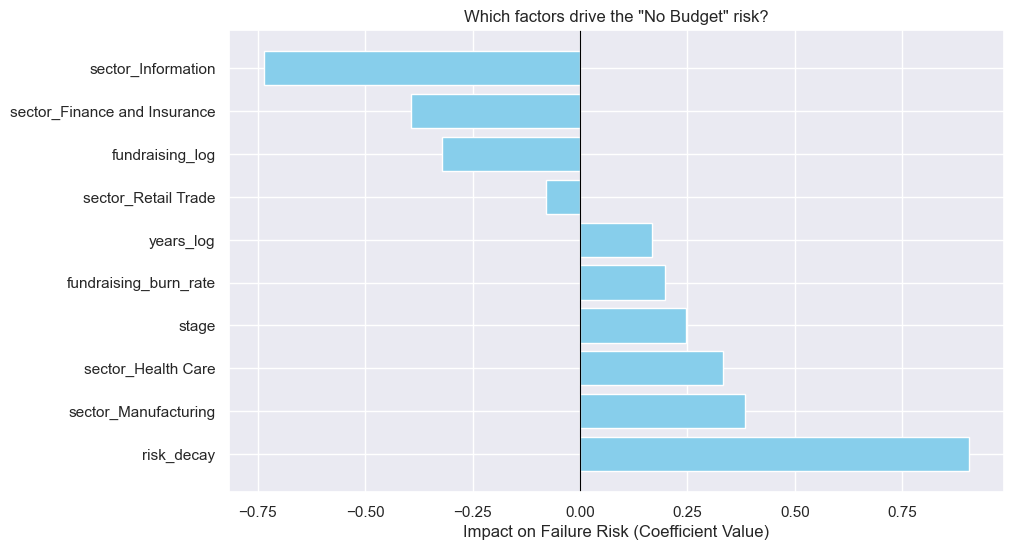

In [40]:
# Which variables are driving the risk?
# Extract coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_no_budget.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
plt.xlabel('Impact on Failure Risk (Coefficient Value)')
plt.title('Which factors drive the "No Budget" risk?')
plt.axvline(0, color='black', lw=0.8)
plt.show()

In [41]:
#Startups with high risk_decay 
highest_risk_decay_startups=df_startups_failure.sort_values(by="risk_decay", ascending=False).head(10)
print(highest_risk_decay_startups[['name','what_they_did','year_of_operation', 'risk_decay', 'fundraising_log', 'no_budget']])

                   name                      what_they_did  year_of_operation  \
19               Driver              Cancer trial matching                  0   
0             Airy Labs  Educational mobile games for kids                  2   
3                 Burbn    Check-in app with photo-sharing                  2   
154          Hot Potato                Social check-in app                  2   
9    Dyson's EV Project                   Electric vehicle                  2   
6          Coinbase NFT                    NFT marketplace                  2   
94        Twitter Music                Music discovery app                  2   
96                 Vdio            Video streaming service                  2   
54             NewsTilt           Platform for journalists                  2   
56             Pets.com         Online pet supply retailer                  2   

     risk_decay  fundraising_log  no_budget  
19     1.000000         0.000000          1  
0      0.548812 

In [42]:
# Random Forest Model
model_no_budget_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Model training
model_no_budget_rf.fit(x_train, y_train)

probability_failure_risk_rf = model_no_budget_rf.predict_proba(x_test)[:, 1]
auc_roc_rf = roc_auc_score(y_test, probability_failure_risk_rf)

print(f"Logistic Regression AUC: 0.73")
print(f"Random Forest AUC: {auc_roc_rf:.2f}")

Logistic Regression AUC: 0.73
Random Forest AUC: 0.74


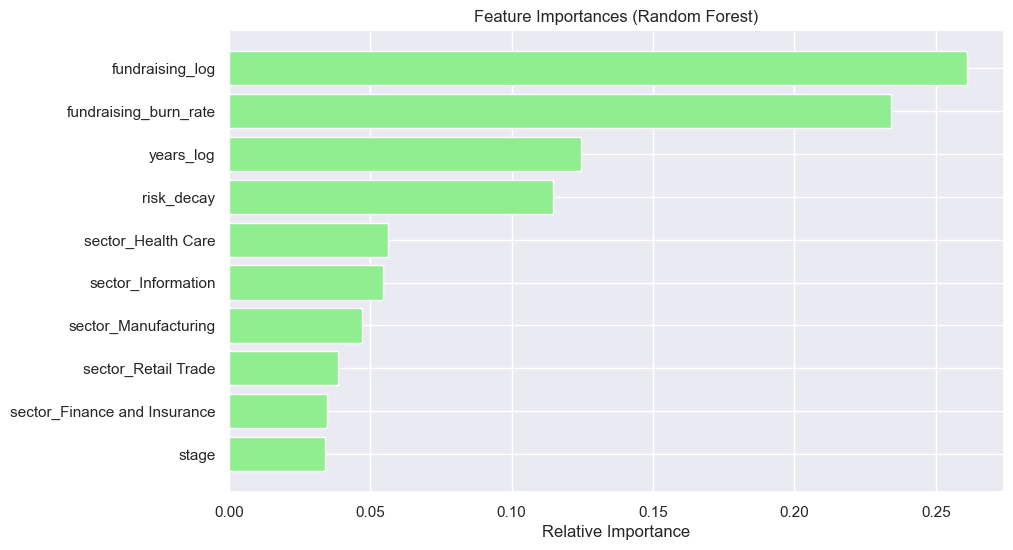

In [43]:
# Feature importances Random Forest model
importances = model_no_budget_rf.feature_importances_
indices = np.argsort(importances)

# Plot
plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='lightgreen', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

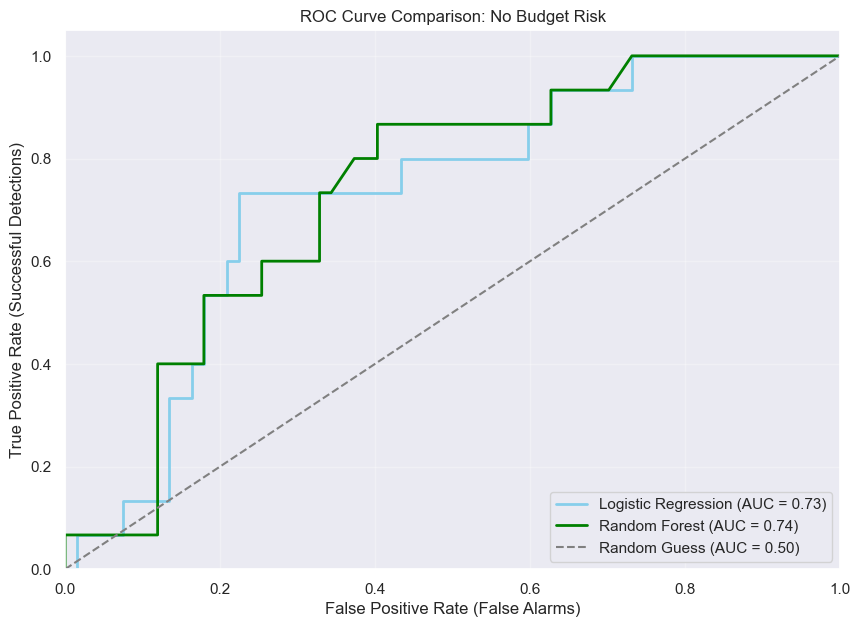

In [44]:
# AUC-ROC Curve plot
# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, probability_failure_risk)
# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, probability_failure_risk_rf)

plt.figure(figsize=(10, 7))

plt.plot(fpr_lr, tpr_lr, color='skyblue', lw=2, 
         label=f'Logistic Regression (AUC = {auc_roc:.2f})')

# Plot Random Forest (Green)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, 
         label=f'Random Forest (AUC = {auc_roc_rf:.2f})')

# Plot the "Random Guess" baseline (The Diagonal)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Successful Detections)')
plt.title('ROC Curve Comparison: No Budget Risk')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

<div class="alert alert-block alert-info">

<b>Results conclusions:</b>  <a class="tocSkip"></a>

-	In this project, two types of models were compared, first Logistic Regression and second, Random Forest. 

-	While Logistic Regression highlights direct linear relationships (like how fast resources are used), the Random Forest reveals "combinatorial" risks where age and budget size interact to create a "danger zone." 

-	For Logistic Regression the main variables to predict failure are:
Risk Decay: it measures how much the chance of a startup failing changes as it gets older. "The longer you stay in the game and the fewer mistakes you make, the safer you become".

<b>Manufacturing & Health Care sectors:</b> these two sectors show a higher probability of failure. These two sectors typically have higher fixed costs and slower paths to monetization, they show a stronger linear correlation with failure when the cash starts to run low, and the Logistic Regression model focuses on how fast a startup uses its resources. It means they have a higher “budget burn rate” than Finance & Insurance and Information sectors.  

<b>Stage:</b> in line with “Risk Decay”, in the first stages of a startup, for the logistic regression model, it has more risk of failing.

-	For Random Forest the main variables to predict failure are:
Fundraising Log: this variable represents a mathematically transformed version of the total amount of money a startup raised during its lifetime. The Log Transformation was used to normalize the scale, ensuring that "Unicorns" (massive raises) didn't skew the model's understanding of the "Average Startup."

<b>Fundraising Burn Rate:</b> it measures how fast a startup uses its budget along years of operation. 

<b>Years:</b> startups years of operation. 

<b>Risk Decay:</b> it is the number 4 variable of failure importance, it is due to the Random Forest looks for relationships between variables and    finds that the size of the budget and how fast it is spent, better determines the probability of failure than just years of operation. 

-	The Variance Inflation factor analysis was used in this project to avoid multicollinearity between variables. For “fundraising log “and “fundraising burn rate” the VIF results was less than 5, meaning there is not multicollinearity (a statistical phenomenon that occurs when two or more of your independent variables are highly correlated with each other). It means that the Random Forest feature importance analysis is correct, and it is based on independent, statistically significant drivers.

-	To determine what were the main reasons for failure for each sector and prevent the models from considering variables that were just noise, the Chi Squared Test was applied, and the variable with a P value lower than 5, were selected:

<b>Finance & Insurance:</b> competition, giants, monetization failure & no budget.

<b>Health Care:</b> giants, monetization failure, no budget and poor market fit. 

<b>Information:</b> execution flaws, no budget and poor market fit.

<b>Manufacturing:</b> competition, giants and no budget. 

<b>Retail Trade:</b> acquisition stagnation, competition and niche limits.

<b>Strategic Recommendations for Founders:</b>

1.	The "Capital Velocity" Trap: it isn't just about how much you raise, but how fast you spend it. Raising a massive budget does not guarantee survival if the burn rate is not matched by growth.
  
2.	Sector-Specific Survival Odds: risks are not distributed equally across industries. The analysis shows that Manufacturing and Health Care face a higher statistical probability of failure than Finance or Information sectors.
  
3.	The "Maturity Shield" (Risk Decay): the goal for early-stage founders is simple: Stay alive. Survival in the first three years significantly lowers your long-term failure probability regardless of your initial budget.
</div>